In [1]:
# Крок 1. Імпорти та ключ доступу

import base64
import io
import os
from pathlib import Path

from dotenv import load_dotenv
from openai import OpenAI
from PIL import Image as PilImage
from IPython.display import Image, display

# Ключ лежить у файлі .env поруч і не потрапляє ні в код, ні в репозиторій.
load_dotenv(".env")
client = OpenAI()

image_dir = Path("images")
image_dir.mkdir(exist_ok=True)
print("ключ знайдено:", bool(os.environ.get("OPENAI_API_KEY")))

ключ знайдено: True


In [2]:
# Крок 2. Промпти

# Задум усіх десяти однаковий: узяти впізнаваний жанр документа і підставити в нього неможливий
# зміст. Око спершу вірить формі, і лише потім помічає, що такого документа існувати не може.
prompts = {
    "01_xray_violin":
        "medical X-ray radiograph of a violin, showing a complete bird skeleton curled inside "
        "the body, wings folded along the ribs, radiologist markers and exposure data in the "
        "corner, blue-grey film, light box glow",
    "02_umbrella_fossil":
        "natural history museum display case, the mounted fossil skeleton of an umbrella "
        "articulated like a pterosaur, ribs and spokes wired to a steel armature, handle as "
        "vertebral column, engraved brass plaque naming the species, dim gallery lighting",
    "03_storm_manual":
        "flat-pack furniture assembly instruction sheet, black and white line art, numbered "
        "steps for assembling a thunderstorm, exploded parts diagram with clouds, bolts, a "
        "lightning bolt and an allen key, a cartoon figure looking puzzled, parts list at the "
        "bottom",
    "04_airport_manuscript":
        "medieval illuminated manuscript page, gold leaf and vermilion, depicting a queue of "
        "travellers at an airport security checkpoint removing their shoes, luggage on a "
        "conveyor belt, monks working as screeners, decorated initial and latin caption, "
        "vellum texture",
    "05_shadow_repair":
        "cluttered repair workshop, a human shadow lying flat on the workbench held down with "
        "metal clamps, a technician in an apron stitching its torn edge with needle and "
        "thread, spare shadows hanging on hooks along the wall, warm tungsten light, shallow "
        "depth of field",
    "06_escalator_dig":
        "1970s archaeological excavation photograph, rectangular dig pit divided by a string "
        "grid, a fully intact escalator unearthed in the sediment layer, its steel steps "
        "still aligned and crusted with dry clay, the comb plate exposed at the lower end, "
        "two archaeologists in sun hats kneeling to brush soil from the handrail, a third "
        "crouching with a clipboard recording measurements, a wooden measuring rod and a "
        "numbered find marker laid beside the steps, spoil heaps, a wheelbarrow and canvas "
        "tent at the pit edge, faded Kodachrome with grain, harsh midday sun, long shadows, "
        "dust hanging in the air",
    "07_botanical_atlas":
        "19th century botanical illustration plate, hand-inked and finished with watercolour "
        "wash, a plant whose stems are taut steel guitar strings and whose seed pods are "
        "wooden tuning pegs, ball-end string tips opening as flower buds, roots coiling like "
        "braided cable, a separate dissection study of a single pod in the lower corner, "
        "latin nomenclature and plate number in copperplate script, aged paper with foxing "
        "and a faint plate mark",
    "08_cloud_blueprint":
        "engineering cutaway diagram of a cumulus cloud drawn on graph paper, exploded view "
        "revealing an internal frame of bolts, rivets, load-bearing struts, pressure valves, "
        "condensation pipes and a hinged access hatch, numbered callouts with leader lines, a "
        "parts key in the corner and a title block with revision number bottom right, "
        "blueprint aesthetic, faded blue ink",
    "09_sky_restoration":
        "art conservation studio, a large panel of blue sky with cumulus clouds laid flat on "
        "a padded work table, a long jagged crack running across it, a conservator in nitrile "
        "gloves retouching the crack with a fine sable brush under a magnifying lamp, pigment "
        "jars, scalpels, cotton swabs and a colour matching chart of blues laid out beside "
        "the panel, several other sky panels of different weather leaning against the wall "
        "awaiting repair, raking light across the surface revealing fine craquelure, daylight "
        "from a tall north window, documentary photograph",
    "10_cello_apartment":
        "wide-angle real estate listing photograph of a small studio apartment built inside a "
        "cello, sofa, rug and floor lamp arranged on the curved spruce floor, daylight "
        "entering through the two f-hole windows, the four strings running overhead like "
        "ceiling beams, a compact kitchenette against the ribs, staged interior styling, "
        "agency watermark in the corner, bright even lighting",
}
print("промптів:", len(prompts))

промптів: 10


In [3]:
# Крок 3. Функції

# Готову картинку заново не замовляємо: якщо файл на місці, беремо його.
# Так перезапуск ноутбука нічого не коштує.
def make_image(name, prompt, model="gpt-image-2", size="1024x1024"):
    path = image_dir / f"{name}.png"
    if path.exists():
        return path, "взято збережене"
    answer = client.images.generate(model=model, prompt=prompt, size=size)
    path.write_bytes(base64.b64decode(answer.data[0].b64_json))
    return path, "згенеровано"


# Для показу зменшуємо копію, повна якість лишається у файлах теки images.
def preview(path, width=820):
    picture = PilImage.open(path)
    height = round(picture.height * width / picture.width)
    buffer = io.BytesIO()
    picture.resize((width, height), PilImage.LANCZOS).convert("RGB").save(
        buffer, format="JPEG", quality=88)
    return Image(data=buffer.getvalue(), format="jpeg")

In [4]:
# Крок 4. Отримуємо всі зображення

pictures = {}
for name, prompt in prompts.items():
    path, how = make_image(name, prompt)
    pictures[name] = path
    print(f"{name:32s} {how:15s} {path.stat().st_size // 1024:5d} КБ")

01_xray_violin                   взято збережене  1417 КБ
02_umbrella_fossil               взято збережене  1546 КБ
03_storm_manual                  взято збережене   949 КБ
04_airport_manuscript            взято збережене  2558 КБ
05_shadow_repair                 взято збережене  1425 КБ
06_escalator_dig                 взято збережене  2166 КБ
07_botanical_atlas               взято збережене  1983 КБ
08_cloud_blueprint               взято збережене  2029 КБ
09_sky_restoration               взято збережене  1660 КБ
10_cello_apartment               взято збережене  2031 КБ


medical X-ray radiograph of a violin, showing a complete bird skeleton curled inside the body, wings folded along the ribs, radiologist markers and exposure data in the corner, blue-grey film, light box glow


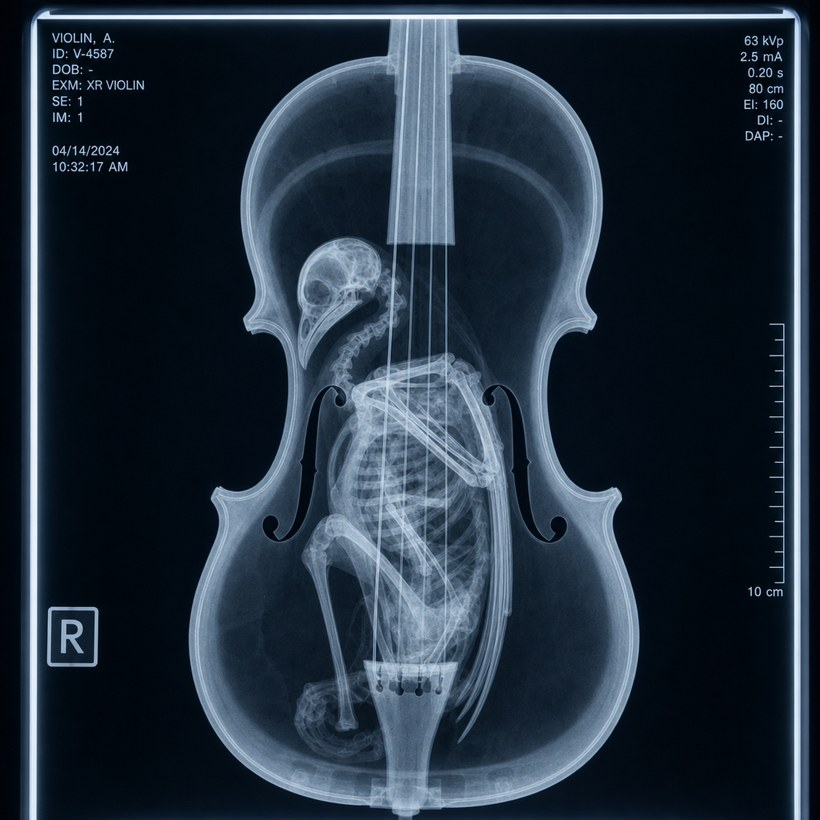

In [5]:
# Крок 5. Рентген скрипки

print(prompts["01_xray_violin"])
display(preview(pictures["01_xray_violin"]))

# Крім скелета модель домалювала підписи, яких я не просив: номер знімка, параметри зйомки
# і лінійку збоку.

natural history museum display case, the mounted fossil skeleton of an umbrella articulated like a pterosaur, ribs and spokes wired to a steel armature, handle as vertebral column, engraved brass plaque naming the species, dim gallery lighting


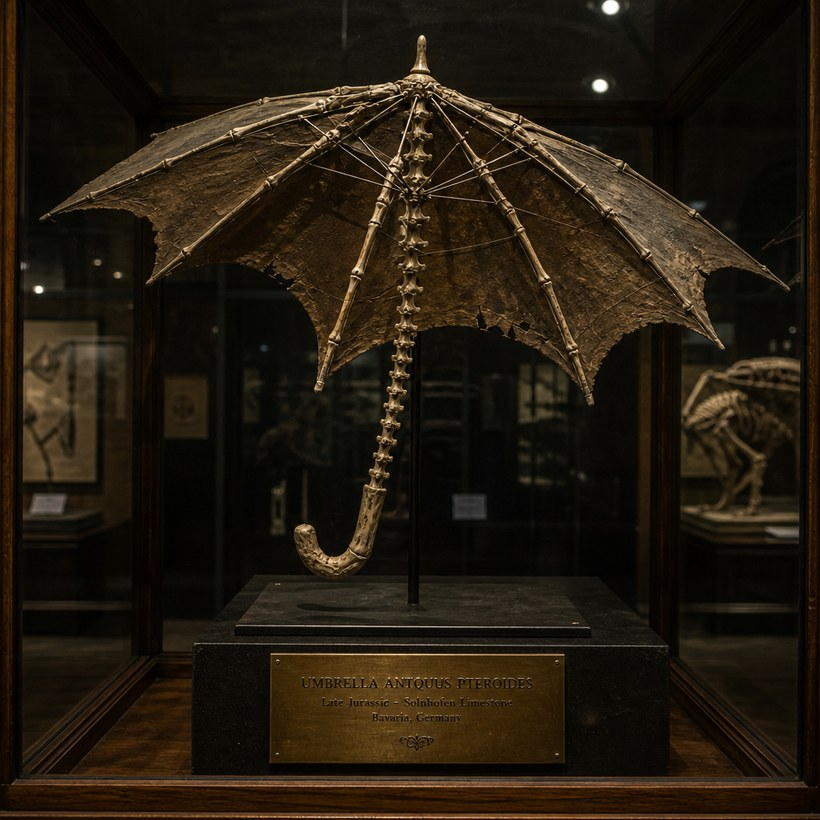

In [6]:
# Крок 6. Скам'яніла парасолька

print(prompts["02_umbrella_fossil"])
display(preview(pictures["02_umbrella_fossil"]))

# На табличці стоїть Зольнгофен, звідки походить археоптерикс.
# У назві виду пропущена літера: ANTQUUS замість ANTIQUUS.

flat-pack furniture assembly instruction sheet, black and white line art, numbered steps for assembling a thunderstorm, exploded parts diagram with clouds, bolts, a lightning bolt and an allen key, a cartoon figure looking puzzled, parts list at the bottom


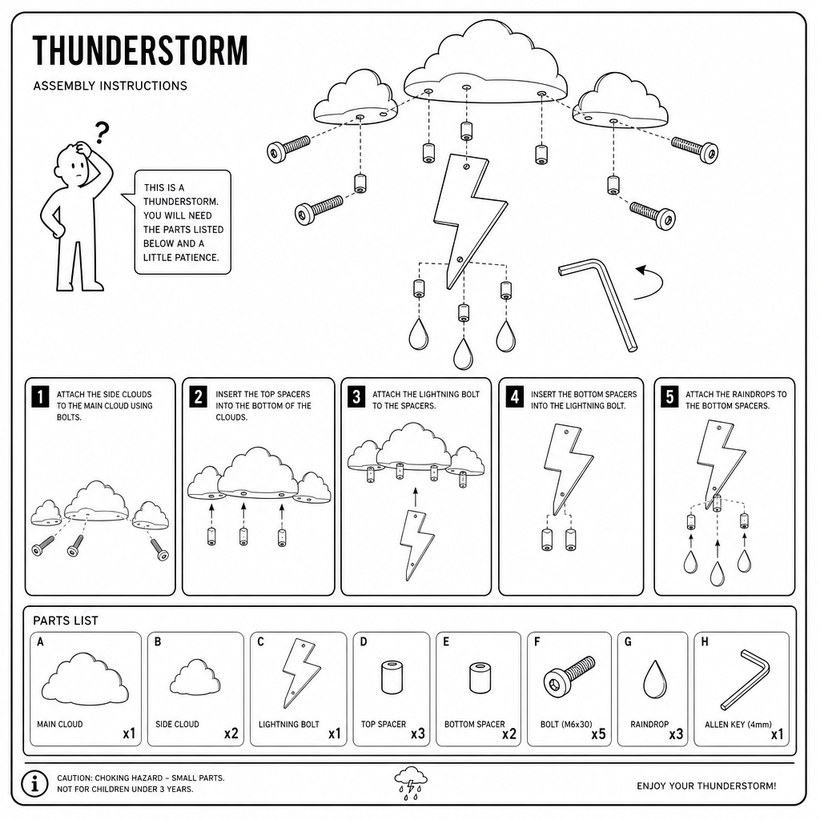

In [7]:
# Крок 7. Інструкція зі складання грози

print(prompts["03_storm_manual"])
display(preview(pictures["03_storm_manual"]))

# Тут вийшло найбільше тексту: п'ять кроків, деталі від A до H з кількостями,
# розмір болта і навіть застереження про дрібні частини.

medieval illuminated manuscript page, gold leaf and vermilion, depicting a queue of travellers at an airport security checkpoint removing their shoes, luggage on a conveyor belt, monks working as screeners, decorated initial and latin caption, vellum texture


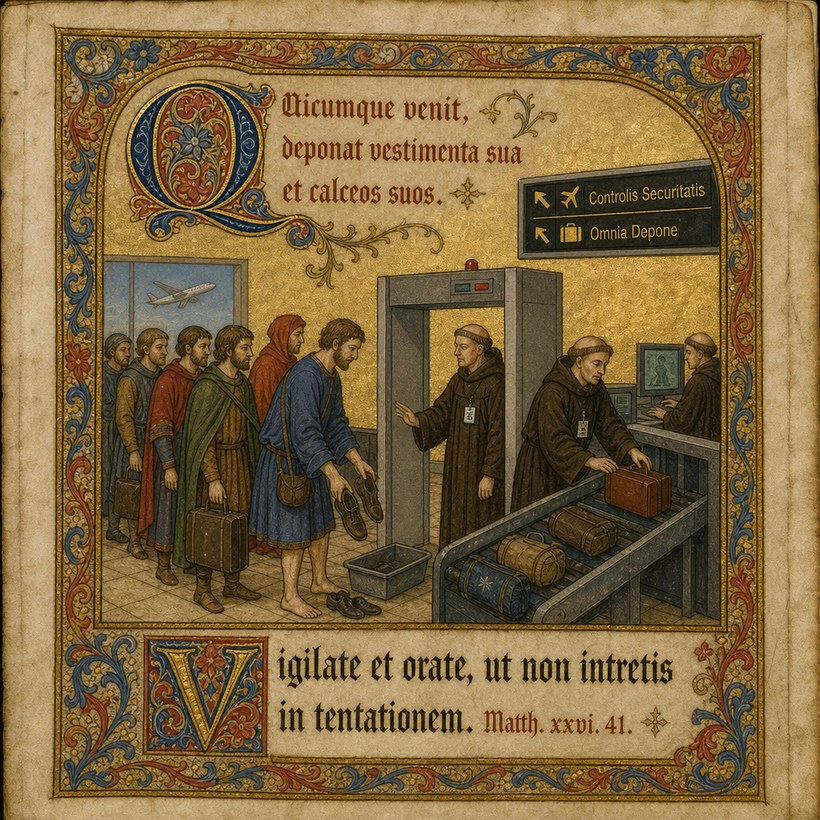

In [8]:
# Крок 8. Аеропорт у середньовічному рукописі

print(prompts["04_airport_manuscript"])
display(preview(pictures["04_airport_manuscript"]))

# Латина тут не для вигляду: угорі написано про зняте взуття, унизу цитата з Матвія
# з посиланням на главу і вірш.

cluttered repair workshop, a human shadow lying flat on the workbench held down with metal clamps, a technician in an apron stitching its torn edge with needle and thread, spare shadows hanging on hooks along the wall, warm tungsten light, shallow depth of field


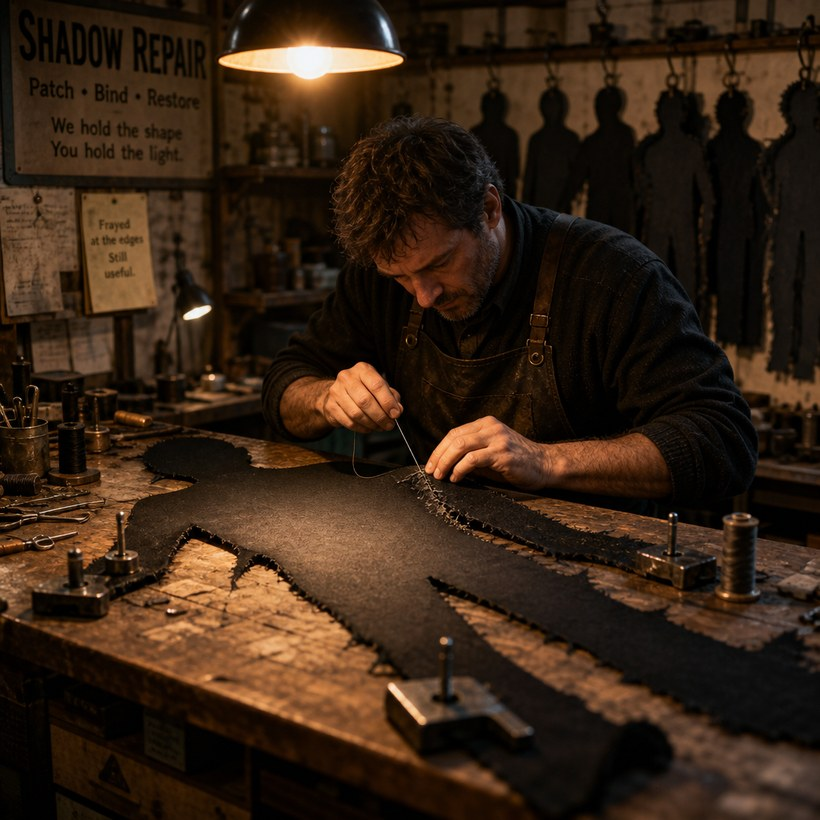

In [9]:
# Крок 9. Майстерня ремонту тіней

print(prompts["05_shadow_repair"])
display(preview(pictures["05_shadow_repair"]))

# Тінь лежить на столі як шматок тканини. Вивіску з гаслом модель придумала сама.

1970s archaeological excavation photograph, rectangular dig pit divided by a string grid, a fully intact escalator unearthed in the sediment layer, its steel steps still aligned and crusted with dry clay, the comb plate exposed at the lower end, two archaeologists in sun hats kneeling to brush soil from the handrail, a third crouching with a clipboard recording measurements, a wooden measuring rod and a numbered find marker laid beside the steps, spoil heaps, a wheelbarrow and canvas tent at the pit edge, faded Kodachrome with grain, harsh midday sun, long shadows, dust hanging in the air


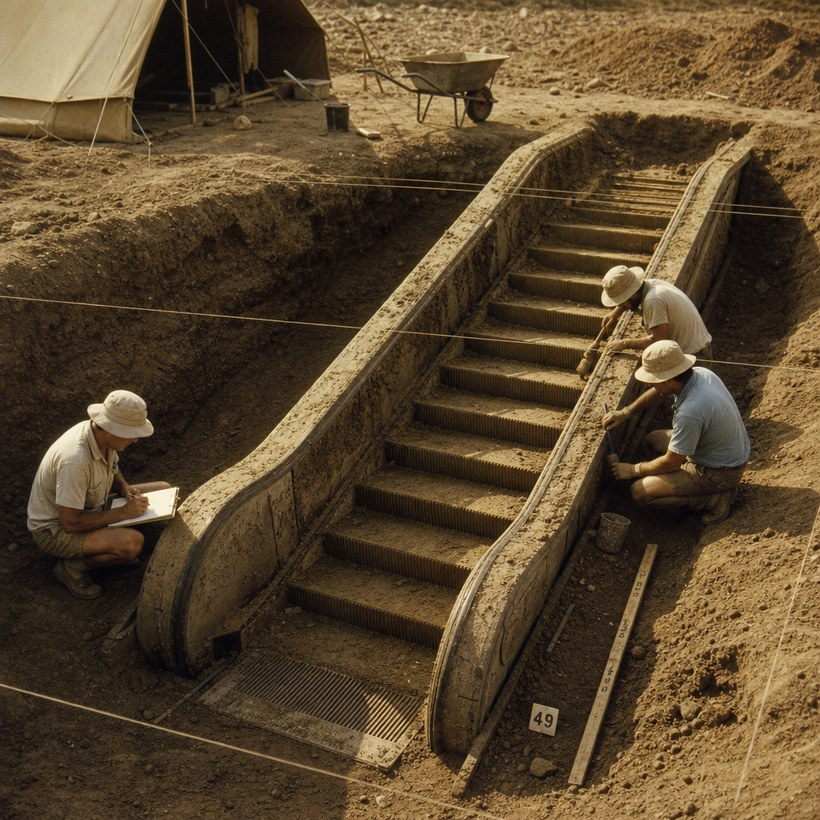

In [10]:
# Крок 10. Ескалатор у розкопі

print(prompts["06_escalator_dig"])
display(preview(pictures["06_escalator_dig"]))

# Спершу я описав сцену коротко, і ескалатор виходив як новий. Дописав про кірку глини,
# гребінку і табличку знахідки, і він став схожий на викопаний.

19th century botanical illustration plate, hand-inked and finished with watercolour wash, a plant whose stems are taut steel guitar strings and whose seed pods are wooden tuning pegs, ball-end string tips opening as flower buds, roots coiling like braided cable, a separate dissection study of a single pod in the lower corner, latin nomenclature and plate number in copperplate script, aged paper with foxing and a faint plate mark


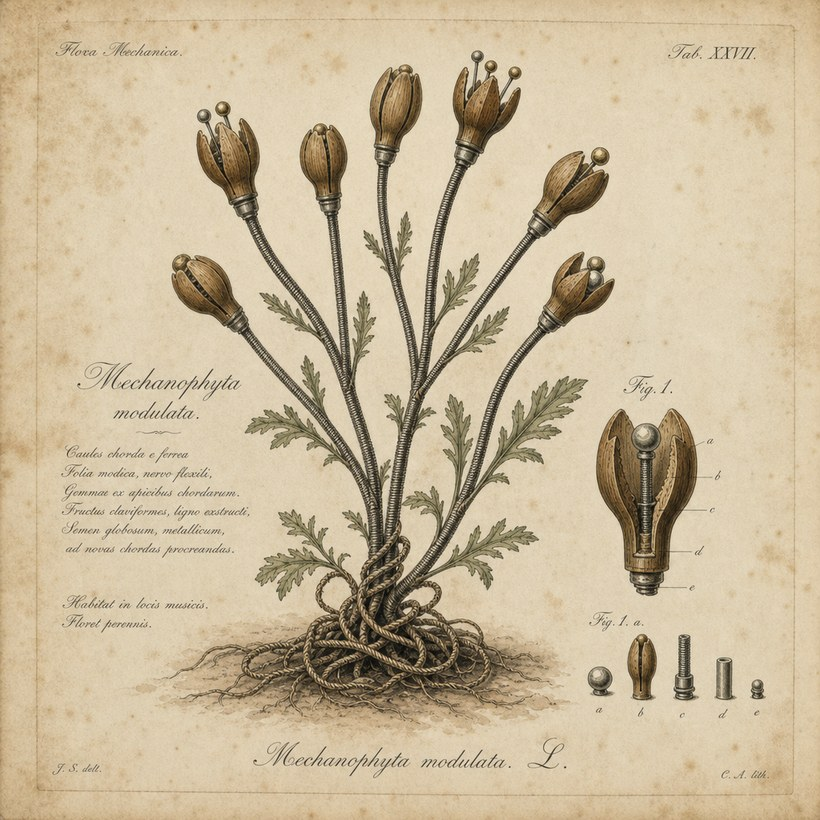

In [11]:
# Крок 11. Атлас рослини зі струн

print(prompts["07_botanical_atlas"])
display(preview(pictures["07_botanical_atlas"]))

# Опис латиною тримається теми: стебла зі струни, насіння металеве для нових струн.

engineering cutaway diagram of a cumulus cloud drawn on graph paper, exploded view revealing an internal frame of bolts, rivets, load-bearing struts, pressure valves, condensation pipes and a hinged access hatch, numbered callouts with leader lines, a parts key in the corner and a title block with revision number bottom right, blueprint aesthetic, faded blue ink


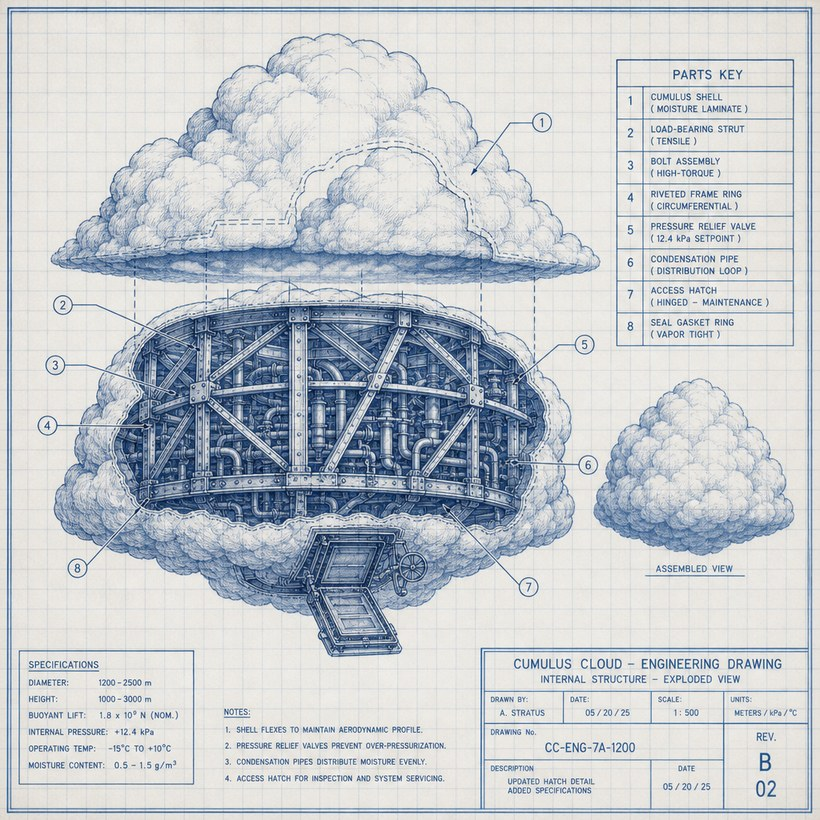

In [12]:
# Крок 12. Хмара в інженерному розрізі

print(prompts["08_cloud_blueprint"])
display(preview(pictures["08_cloud_blueprint"]))

# Той самий тиск 12.4 кПа стоїть на аркуші у двох різних місцях.

art conservation studio, a large panel of blue sky with cumulus clouds laid flat on a padded work table, a long jagged crack running across it, a conservator in nitrile gloves retouching the crack with a fine sable brush under a magnifying lamp, pigment jars, scalpels, cotton swabs and a colour matching chart of blues laid out beside the panel, several other sky panels of different weather leaning against the wall awaiting repair, raking light across the surface revealing fine craquelure, daylight from a tall north window, documentary photograph


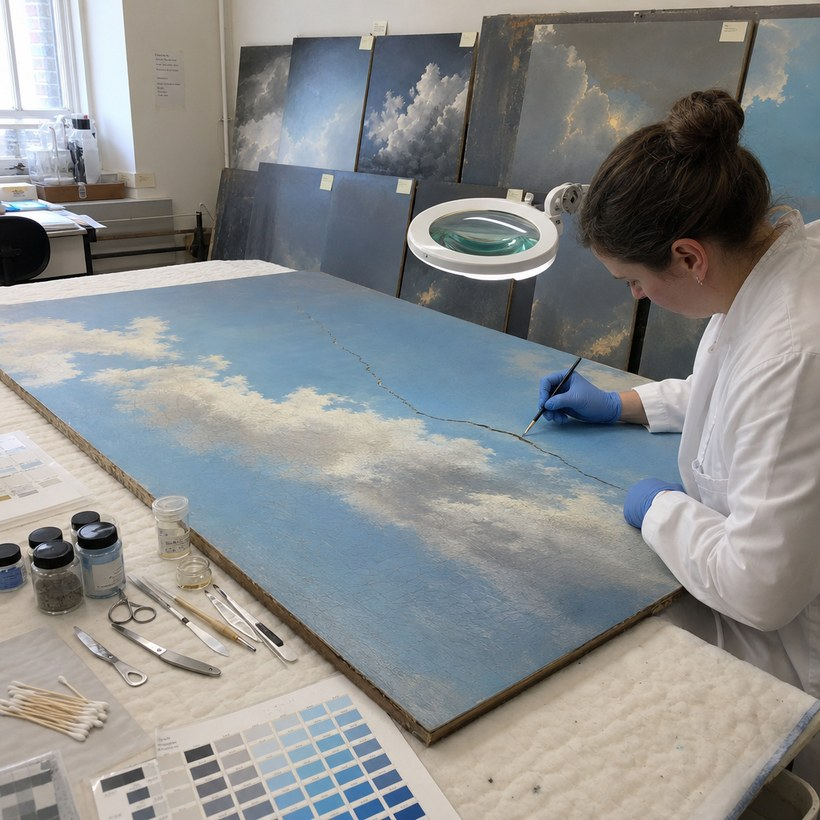

In [13]:
# Крок 13. Реставрація неба

print(prompts["09_sky_restoration"])
display(preview(pictures["09_sky_restoration"]))

# У куті лежить шкала синіх відтінків, по якій добирають тон. Її я теж не замовляв.

wide-angle real estate listing photograph of a small studio apartment built inside a cello, sofa, rug and floor lamp arranged on the curved spruce floor, daylight entering through the two f-hole windows, the four strings running overhead like ceiling beams, a compact kitchenette against the ribs, staged interior styling, agency watermark in the corner, bright even lighting


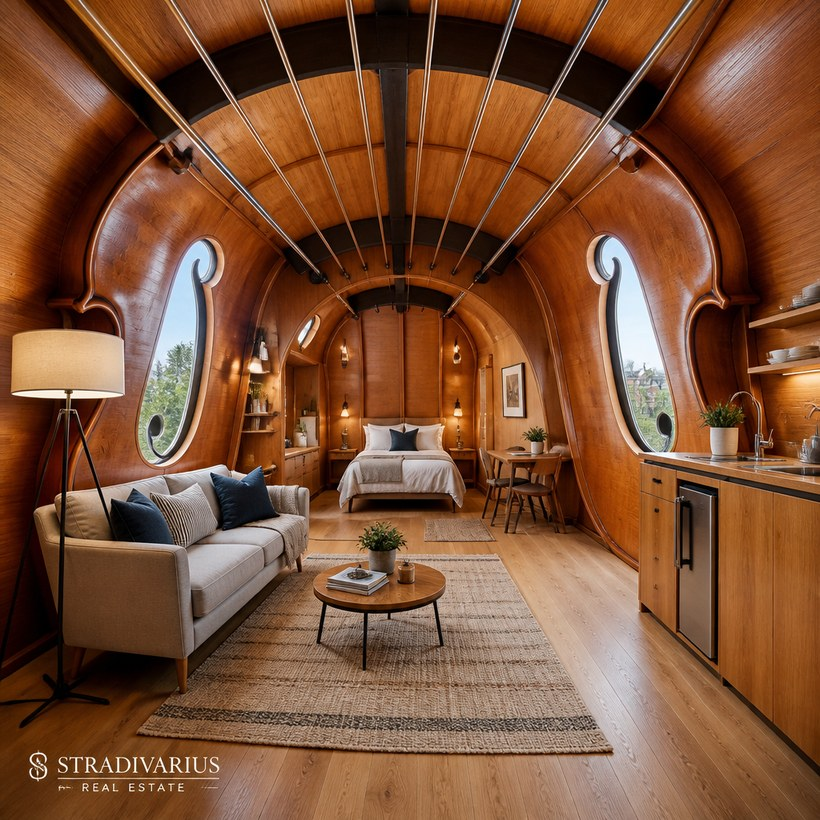

In [14]:
# Крок 14. Квартира всередині віолончелі

print(prompts["10_cello_apartment"])
display(preview(pictures["10_cello_apartment"]))

# Ефи стали вікнами, струни балками. Назву агенції модель придумала сама.

In [15]:
# Крок 15. Що вийшло

# Десять зображень зроблені моделлю gpt-image-2 за текстовими описами, розміром 1024 на 1024.
# Кожне в іншому жанрі: медичний знімок, музейна вітрина, складальна схема, рукописна мініатюра,
# фото майстерні, фото розкопок, гравюра, креслення, студійне фото, риелторський знімок.

# Найбільше здивували написи. Я їх майже не задавав, а модель дописала сама: параметри зйомки,
# геологічний період на музейній табличці, перелік деталей з кількостями, латинську цитату
# з посиланням на главу і вірш.

# Помилка теж є: у назві виду на музейній табличці пропущена літера.

# Про промпти. Коли я дописував речові подробиці і те, що роблять люди в кадрі, картинка ставала
# ближчою до задуманого. Від слів про якість зображення нічого не мінялось.